In [1]:
import os
import numpy as np
import pandas as pd
import rasterio as rio
import geopandas as gpd
from statistics import mean
import matplotlib.pyplot as plt
from matplotlib import colors, cm
from scipy.stats import gaussian_kde

import netCDF4 as nc
from pyproj import CRS
from osgeo import gdal
from glob import glob

# NC数据转TIF

In [2]:
years = list(range(2015, 2021))
x_res, y_res = 0.01, 0.01

for year in years:
    nc_path = glob(os.path.join('./nc/', f'*{year}*.nc'))[0]
    tif_path = os.path.join('./tif/', f'{year}.tif')
    # 获取分辨率和左上角像素坐标值
    rootgrp = nc.Dataset(nc_path)
    lon = rootgrp['lon'][...].data
    lat = rootgrp['lat'][...].data
    x_min, y_max = lon.min(), lat.max()
    # 仿射变换六参数
    gt = (x_min, x_res, 0, y_max, 0, -y_res)
    # 获取地理坐标系
    crs = CRS.from_epsg(4326)
    wkt = crs.to_wkt()
    # 读取数据
    pm = rootgrp['GWRPM25'][::-1, :]
    pm = pm.filled(np.nan)
    # 创建GeoTIFF文件并写入数据
    driver = gdal.GetDriverByName('GTiff')
    ds = driver.Create(tif_path, pm.shape[1], pm.shape[0], 1, 
                       gdal.GDT_Float32, options=["COMPRESS=LZW"])
    ds.SetGeoTransform(gt)
    ds.SetProjection(wkt)
    band = ds.GetRasterBand(1)
    band.WriteArray(pm)
    band.SetNoDataValue(np.nan)

ds = band = None

# 站点数据准备

In [3]:
df = pd.read_csv('pm25.csv')
df.dropna(subset=["lon", "lat"], inplace=True)
df.shape

(2016, 15)

In [4]:
extent = [73.00499725341797, 139.9949951171875, 18.0049991607666, 53.994998931884766]
def in_extent(row):
    lon, lat = row['lon'], row['lat']
    if lon<extent[0] or lon>extent[1]:
        return False
    if lat<extent[2] or lat>extent[3]:
        return False
    return True
mask = df.apply(in_extent, axis=1)
df = df.loc[mask, :]
df.shape

(2014, 15)

In [5]:
pm_gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df['lon'], df['lat']), crs='EPSG:4326')
pm_gdf.head(1)

,station,y2014,y2015,y2016,y2017,y2018,y2019,y2020,y2021,y2022,name,city,lon,lat,contrast,geometry
0,1013A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,市监测中心(停运150702),天津,117.151,39.097,Y,POINT (117.15100 39.09700)


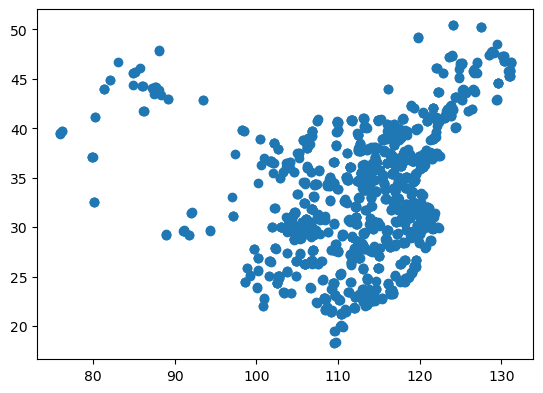

In [6]:
pm_gdf.plot();

# 计算每个站点对应的反演的PM2.5浓度

In [7]:
years = [2015, 2016, 2017, 2018, 2019, 2020]
for year in years:
    src = rio.open(f'./tif/{year}.tif')
    band = src.read(1)
    for i in pm_gdf.index:
        lon, lat = pm_gdf.loc[i, 'lon'], pm_gdf.loc[i, 'lat']
        row, col = src.index(lon, lat)
        # 获取指定行列号的像元值
        value = band[row, col]
        pm_gdf.loc[i, f'r{year}'] = value
pm_gdf.head(1)

,station,y2014,y2015,y2016,y2017,y2018,y2019,y2020,y2021,y2022,...,lon,lat,contrast,geometry,r2015,r2016,r2017,r2018,r2019,r2020
0,1013A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,117.151,39.097,Y,POINT (117.15100 39.09700),69.199997,70.300003,62.0,54.700001,53.200001,52.099998


# 绘图

In [8]:
from sklearn.metrics import mean_squared_error

In [9]:
# matplotlib其实是不支持显示中文的 显示中文需要一行代码设置字体
plt.rcParams['font.family'] = 'SimHei'
plt.rcParams['axes.unicode_minus'] = False   # 步骤二（解决坐标轴负数的负号显示问题）

In [10]:
def get_xyz(year):
    real = pm_gdf.loc[:, f'y{year}'].to_numpy()
    pred = pm_gdf.loc[:, f'r{year}'].to_numpy()
    mask1 = ~np.isnan(real)
    mask2 = ~np.isnan(pred)
    mask = mask1 & mask2
    real = real[mask]
    pred = pred[mask]
    # Calculate the point density
    xy = np.vstack([real, pred])  #  将两个维度的数据叠加
    z = gaussian_kde(xy)(xy)  # 建立概率密度分布，并计算每个样本点的概率密度
    return real, pred, z

In [11]:
def get_regression_line(real, pred, data_range=(0, 110)):
    # 拟合（若换MK，自行操作）最小二乘
    def slope(xs, ys):
        m = (((mean(xs) * mean(ys)) - mean(xs * ys)) / ((mean(xs) * mean(xs)) - mean(xs * xs)))
        b = mean(ys) - m * mean(xs)
        return m, b
    k, b = slope(real, pred)
    regression_line = []
    for a in range(data_range[0], data_range[1]+1):
        regression_line.append((k * a) + b)
    return regression_line

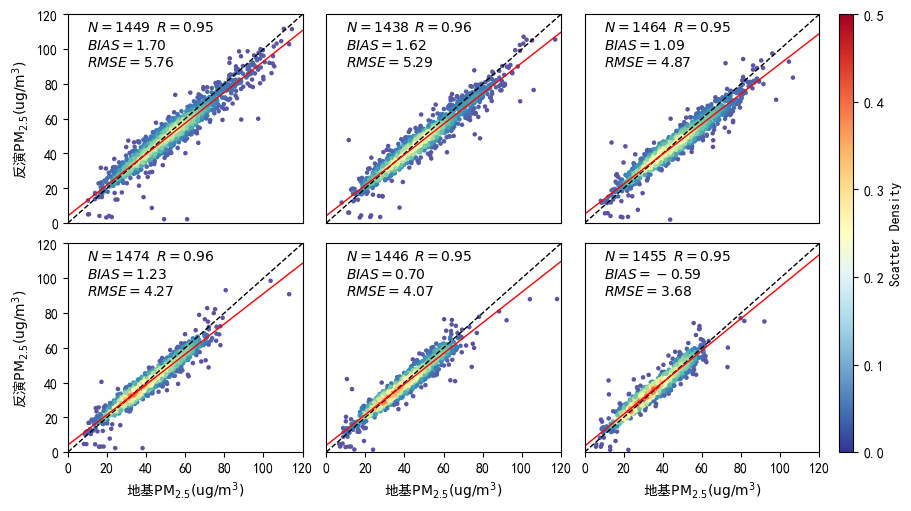

In [12]:
# 绘图，可自行调整颜色等等
fig, axs = plt.subplots(2, 3, constrained_layout=True, figsize=(9, 5))
years = [2015, 2016, 2017, 2018, 2019, 2020]
i = 1
vmin, vmax = 0, 0.5
for year, ax in zip(years, axs.flatten()):
    real, pred, z = get_xyz(year)
    scatter = ax.scatter(real, pred, marker='o', c=z*100, edgecolors=None, s=5, 
                         label='LST', cmap='Spectral_r', vmin=vmin, vmax=vmax)
    ax.plot([0, 120], [0, 120], 'k--', lw=1)  # 画的1:1线，线的颜色为black，线宽为0.8
    regression_line = get_regression_line(real, pred, data_range=(0, 120))
    ax.plot(regression_line, 'r-', lw=1.)      # 预测与实测数据之间的回归线
    if i>3:
        ax.set_xlabel('地基$\mathrm{PM_{2.5}(ug/m^3)}$')
    if i==1 or i==4:
        ax.set_ylabel('反演$\mathrm{PM_{2.5}(ug/m^3)}$')
    if i<4:
        ax.axes.xaxis.set_visible(False)
    if i in [2, 3, 5, 6]:
        ax.axes.yaxis.set_visible(False)
    ax.set_xlim(0, 120) # 设置x坐标轴的显示范围
    ax.set_xticks(range(0, 121, 20))
    ax.set_ylim(0, 120) # 设置y坐标轴的显示范围
    x, y = real, pred
    BIAS = mean(x - y)
    MSE = mean_squared_error(x, y)
    RMSE = np.power(MSE, 0.5)
    R = np.corrcoef(x, y)[0, 1]
    ax.text(10, 110, '$N=%.f$' % len(y), family = 'Times New Roman') # text的位置需要根据x,y的大小范围进行调整。
    ax.text(45, 110, '$R=%.2f$' % R, family = 'Times New Roman')
    ax.text(10, 100, '$BIAS=%.2f$' % BIAS, family = 'Times New Roman')
    ax.text(10, 90, '$RMSE=%.2f$' % RMSE, family = 'Times New Roman')
    i += 1
cbar = fig.colorbar(cm.ScalarMappable(norm=colors.Normalize(vmin=vmin, vmax=vmax), cmap="RdYlBu_r"), 
                    pad=0.012, orientation='vertical', aspect=30, ax=axs, label='Scatter Density')

In [13]:
fig.savefig('./result.jpg', dpi=1000, bbox_inches='tight')